In [1]:
from pykawa.cross_sections import CrossSection, CrossSectionInterpolator
from pykawa.utils import get_phases
import numpy as np
import matplotlib.pyplot as plt

In [6]:
from importlib.resources import files

def make_cross_section_interpolator(potential, cross_section_type='VISCOSITY',
                                    v=None, v_power=4.0):
    """
    Build a CrossSectionInterpolator from the precomputed phase shift data
    for a given potential.

    Parameters
    ----------
    potential : str
        Either 'ATTRACTIVE_YUKAWA' or 'REPULSIVE_YUKAWA'.
    cross_section_type : str, optional
        One of 'VISCOSITY', 'MOMENTUM', or 'TOTAL'. Default is 'VISCOSITY'.
    v : ndarray, optional
        Velocity array in km/s at which to evaluate the cross section.
        Defaults to np.logspace(-1, 4, 100).
    v_power : float, optional
        Power law index for high-velocity extrapolation. Default is 4.0.

    Returns
    -------
    CrossSectionInterpolator
    """
    if v is None:
        v = np.logspace(-1, 4, 100)
    
    scale = 10 if potential == 'REPULSIVE_YUKAWA' else 100
    data = np.load(files("pykawa.data").joinpath(f"{potential}_phases.npz"))
    mphi_vals  = data["mphi"]
    alpha_vals = data["alpha"]

    log10_mass_ratio_values = mphi_vals / scale
    log10alpha_values       = -alpha_vals / scale
    print(log10_mass_ratio_values)
    print(log10alpha_values)
    n_alpha = len(log10alpha_values)
    n_mr    = len(log10_mass_ratio_values)
    cross_section_table = np.empty((n_alpha, n_mr, len(v)))
    v_grid_table = np.empty((n_alpha, n_mr, 25))
    
    for i, log10alpha in enumerate(log10alpha_values):
        for j, log10_mass_ratio in enumerate(log10_mass_ratio_values):
            print(log10alpha, log10_mass_ratio)
            v_grid, phases = get_phases(log10_mass_ratio, log10alpha, potential)
            cross = CrossSection.from_phase_shifts(
                v_grid, phases,  # v_grid is already log10(v)
                cross_section_type, log10alpha, log10_mass_ratio,
                v_power=v_power
                    )
            cross_section_table[i, j, :] = cross(v, None)
            v_grid_table[i, j, :] = v_grid
    cross_section_interpolator = CrossSectionInterpolator(v, log10alpha_values, log10_mass_ratio_values,
                                    cross_section_table)
    return cross_section_interpolator, cross_section_table, log10_mass_ratio_values, log10alpha_values, v_grid_table

cross_section_interpolator_attractive, *_ = make_cross_section_interpolator('ATTRACTIVE_YUKAWA')

[3.5  3.53 3.56 3.59 3.62 3.65 3.68 3.71 3.74 3.77 3.8  3.83 3.86 3.89
 3.92 3.95 3.98 4.01 4.04 4.07 4.1  4.13 4.16 4.19 4.22 4.25 4.28 4.31
 4.34 4.37 4.4  4.43 4.46 4.49 4.52 4.55 4.58 4.61 4.64 4.67 4.7 ]
[-2.6  -2.65 -2.7  -2.75 -2.8  -2.85 -2.9  -2.95 -3.   -3.05 -3.1  -3.15
 -3.2  -3.25 -3.3  -3.35 -3.4  -3.45 -3.5  -3.55 -3.6  -3.65 -3.7  -3.75
 -3.8  -3.85 -3.9  -3.95 -4.   -4.05 -4.1  -4.15 -4.2  -4.25 -4.3  -4.35
 -4.4  -4.45 -4.5  -4.55 -4.6 ]


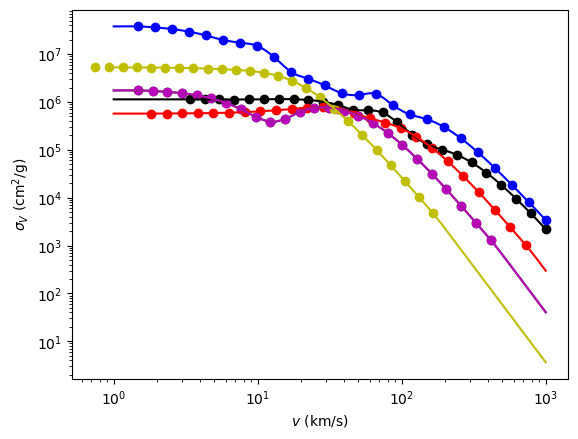

In [15]:
log10_mass_ratio_plot = [3.86, 4.13, 4.22, 4.22, 4.22, 4.52]
log10_alpha_plot = [-2.6, -3.1, -2.6, -3.5, -3.5, -4.0]
v_extended = np.logspace(0, 3, 100)
cols = ['k', 'r', 'b', 'g', 'm', 'y']
for i, (log10_mass_ratio, log10_alpha) in enumerate(zip(log10_mass_ratio_plot, log10_alpha_plot)):
    v_grid, phases = get_phases(log10_mass_ratio, log10_alpha, 'ATTRACTIVE_YUKAWA')
    cross = CrossSection.from_phase_shifts(
        v_grid, phases, 'VISCOSITY', log10_alpha, log10_mass_ratio
    )
    v_lin = 10 ** v_grid
    sigma_exact = cross(v_lin, None)

    plt.scatter(v_lin, sigma_exact, color=cols[i])
    plt.loglog(v_extended, cross_section_interpolator_attractive(v_extended, None, log10_alpha, log10_mass_ratio),
               color=cols[i])

plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()

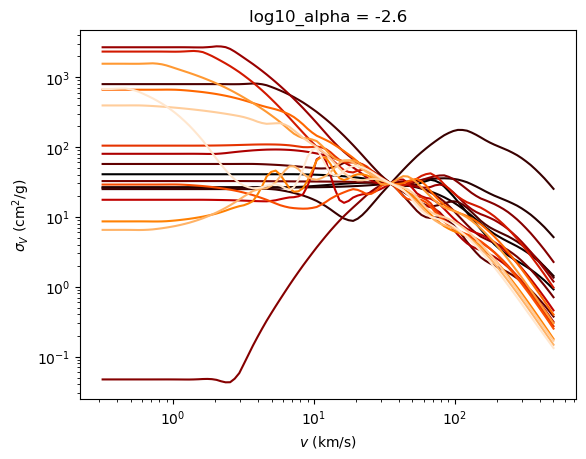

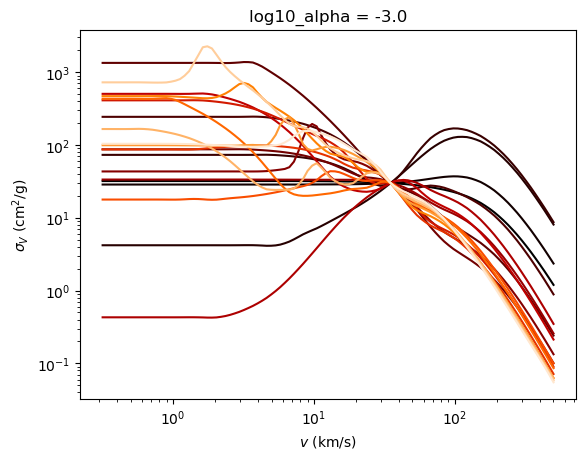

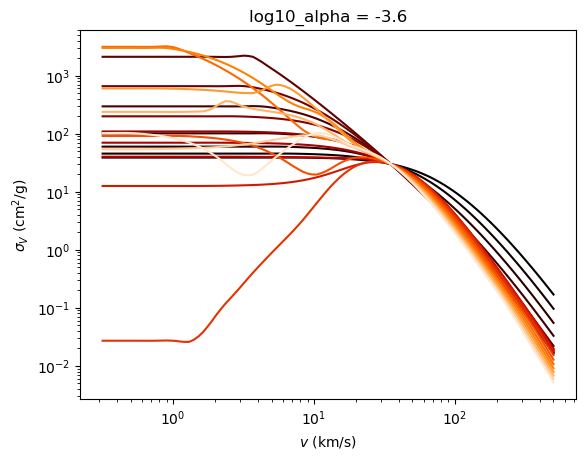

In [22]:
cmap = plt.get_cmap('gist_heat')

log10_mass_ratio_plot = np.linspace(3.5, 4.7, 20)
log10_alpha = -2.6
v = np.logspace(-0.5, 2.7, 100)
colors = [cmap(i/len(log10_mass_ratio_plot)) for i in range(0, len(log10_mass_ratio_plot))]

amp_at_vref = 30
for i, log10_mass_ratio in enumerate(log10_mass_ratio_plot):
    sigma = cross_section_interpolator_attractive(v, amp_at_vref, log10_alpha, log10_mass_ratio)
    plt.loglog(v, sigma,
              color=colors[i])

plt.title('log10_alpha = '+str(log10_alpha))
plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()

log10_mass_ratio_plot = np.linspace(3.5, 4.7, 20)
log10_alpha = -3.0
v = np.logspace(-0.5, 2.7, 100)
colors = [cmap(i/len(log10_mass_ratio_plot)) for i in range(0, len(log10_mass_ratio_plot))]

amp_at_vref = 30
for i, log10_mass_ratio in enumerate(log10_mass_ratio_plot):
    sigma = cross_section_interpolator_attractive(v, amp_at_vref, log10_alpha, log10_mass_ratio)
    plt.loglog(v, sigma,
              color=colors[i])

plt.title('log10_alpha = '+str(log10_alpha))
plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()

log10_mass_ratio_plot = np.linspace(3.5, 4.7, 20)
log10_alpha = -3.6
v = np.logspace(-0.5, 2.7, 100)
colors = [cmap(i/len(log10_mass_ratio_plot)) for i in range(0, len(log10_mass_ratio_plot))]

amp_at_vref = 30
for i, log10_mass_ratio in enumerate(log10_mass_ratio_plot):
    sigma = cross_section_interpolator_attractive(v, amp_at_vref, log10_alpha, log10_mass_ratio)
    plt.loglog(v, sigma,
              color=colors[i])

plt.title('log10_alpha = '+str(log10_alpha))
plt.xlabel(r'$v$ (km/s)')
plt.ylabel(r'$\sigma_V$ (cm$^2$/g)')
plt.show()

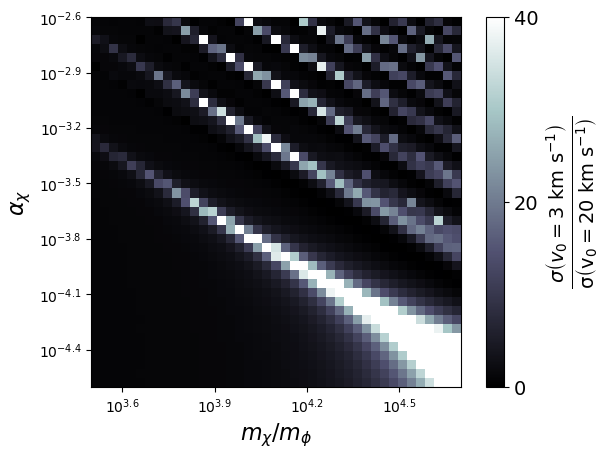

In [28]:
v_eval_low = 3
v_eval_high = 20
mphi_list = np.round(np.arange(3.5, 4.7, 0.03), 2)
alpha_list = np.round(np.arange(-4.6, -2.55, 0.05), 2)

sigma_v_low = np.empty((len(mphi_list), len(alpha_list)))
sigma_v_high = np.empty((len(mphi_list), len(alpha_list)))

amp_at_vref = 10

for i, log10mphi in enumerate(mphi_list):
    for j, log10alpha in enumerate(alpha_list):
        sigma_v_low[i, j] = cross_section_interpolator_attractive(v_eval_low, amp_at_vref, log10alpha, log10mphi)
        sigma_v_high[i, j] = cross_section_interpolator_attractive(v_eval_high, amp_at_vref, log10alpha, log10mphi)
        # sigma_v_low[i, j] = cross_section_interpolator_attractive.thermal_average(
        #     v_eval_low, 10, log10alpha, log10mphi)
        # sigma_v_high[i, j] = cross_section_interpolator_attractive.thermal_average(
        #     v_eval_high, 10, log10alpha, log10mphi)

fig = plt.figure()
ax = plt.subplot(111)
extent = [mphi_list[0], mphi_list[-1], alpha_list[0], alpha_list[-1]]
aspect = (mphi_list[-1] - mphi_list[0]) / (alpha_list[-1] - alpha_list[0])
im = ax.imshow((sigma_v_low / sigma_v_high).T,
               origin='lower',
               cmap='bone',
               extent=extent,
               aspect=aspect,
               vmin=0.,
               vmax=40)
ax.set_xticks([3.6, 3.9, 4.2, 4.5])
ax.set_xticklabels([r'$10^{3.6}$', r'$10^{3.9}$', r'$10^{4.2}$', r'$10^{4.5}$'])
ax.set_yticks([-4.4, -4.1, -3.8, -3.5, -3.2, -2.9, -2.6])
ax.set_yticklabels([r'$10^{-4.4}$', r'$10^{-4.1}$', r'$10^{-3.8}$', r'$10^{-3.5}$', r'$10^{-3.2}$',
                    r'$10^{-2.9}$', r'$10^{-2.6}$'])
cbar = plt.colorbar(im, ticks=[0, 20, 40, 60, 80])
cbar.set_ticklabels([0, 20, 40, 60, 80], fontsize=14)
ax.set_xlabel(r'$m_{\chi} / m_{\phi}$', fontsize=16)
ax.set_ylabel(r'$\alpha_{\chi}$', fontsize=16)
cbar.set_label(r'$\frac{\sigma\left(v_0=3 \ \rm{km} \ \rm{s^{-1}}\right)}{\sigma\left(v_0=20 \ \rm{km} \ \rm{s^{-1}}\right)}$',
               fontsize=20)
plt.savefig('attractive_sigmalowhigh.pdf', bbox_inches='tight')